# Introduction to Rasterio

## Table of Contents
1. [Import Libraries](#1)
2. [Open the image file](#2)
3. [Raster data property](#3) 
4. [Visualizing the raster data](#4)
5. [Raster map algebra](#5)   

## 1. Import Libraries 

In [26]:
import os
import rasterio as rio
from rasterio.plot import show
from rasterio.plot import show_hist

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


## 2. Open the image file

In [27]:
# unzip your data and get the data directory path   
os.chdir(r'C:\Users\Wenge\Hunter College Dropbox\Wenge Ni-Meister\Teaching\GTECH\data\NYC_IKONOS')
#os.chdir(r'C:\Users\Wenge\Hunter College Dropbox\Wenge Ni-Meister\Teaching\GTECH\331&731\2025F_331&731\data\module10\IKONOS')
os.getcwd()

'C:\\Users\\Wenge\\Hunter College Dropbox\\Wenge Ni-Meister\\Teaching\\GTECH\\data\\NYC_IKONOS'

In [28]:
# open the IKONOS images - multispectral bands in one image
fn = 'IKOM_MidNYC_2001-07-03'
nyc = rio.open(fn)

## 3 Read raster file property  

In [29]:
type(nyc)

rasterio.io.DatasetReader

In [30]:
# projection
nyc.crs

CRS.from_wkt('PROJCS["unnamed",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-75],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["Meter",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]')

In [31]:
#column, row and bands
print(nyc.width)
print(nyc.height)
print(nyc.count)

1073
1539
4


In [13]:
# bound of the image
nyc.bounds

BoundingBox(left=585737.749, bottom=4512982.492, right=590029.749, top=4519138.492)

In [32]:
# data format
nyc.driver

'ENVI'

In [33]:
#  Affine transform 
nyc.transform

Affine(4.0, -0.0, 585737.749,
       -0.0, -4.0, 4519138.492)

In [16]:
nyc.meta

{'driver': 'ENVI',
 'dtype': 'uint16',
 'nodata': None,
 'width': 1073,
 'height': 1539,
 'count': 4,
 'crs': CRS.from_wkt('PROJCS["unnamed",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-75],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["Meter",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'),
 'transform': Affine(4.0, -0.0, 585737.749,
        -0.0, -4.0, 4519138.492)}

In [34]:
nyc_band = nyc.read()
type(nyc_band)

numpy.ndarray

## 4 Visualize the raster layers 

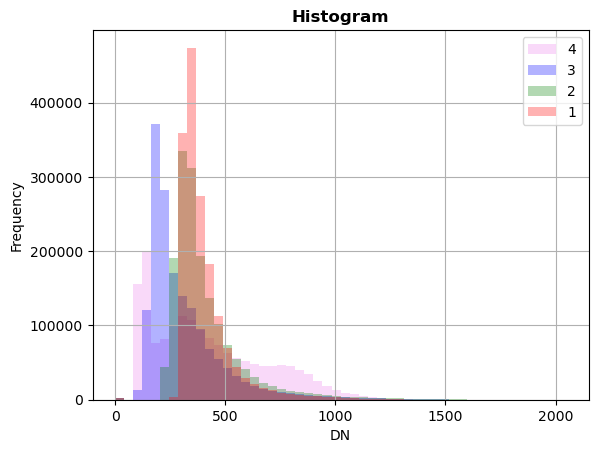

In [35]:
# Histogram of the raster data
show_hist(nyc, bins=50, lw=0.0, stacked=False, alpha=0.3,
      histtype='stepfilled', title='Histogram')

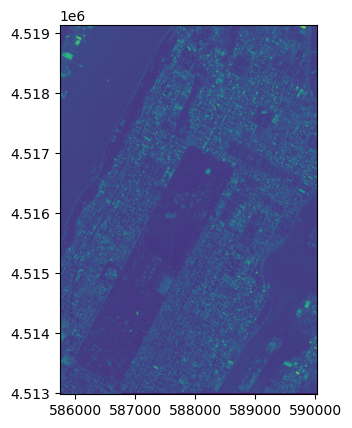

<Axes: >

In [36]:
# plot band 1
show(nyc,1)

Text(0.5, 1.0, 'NIR')

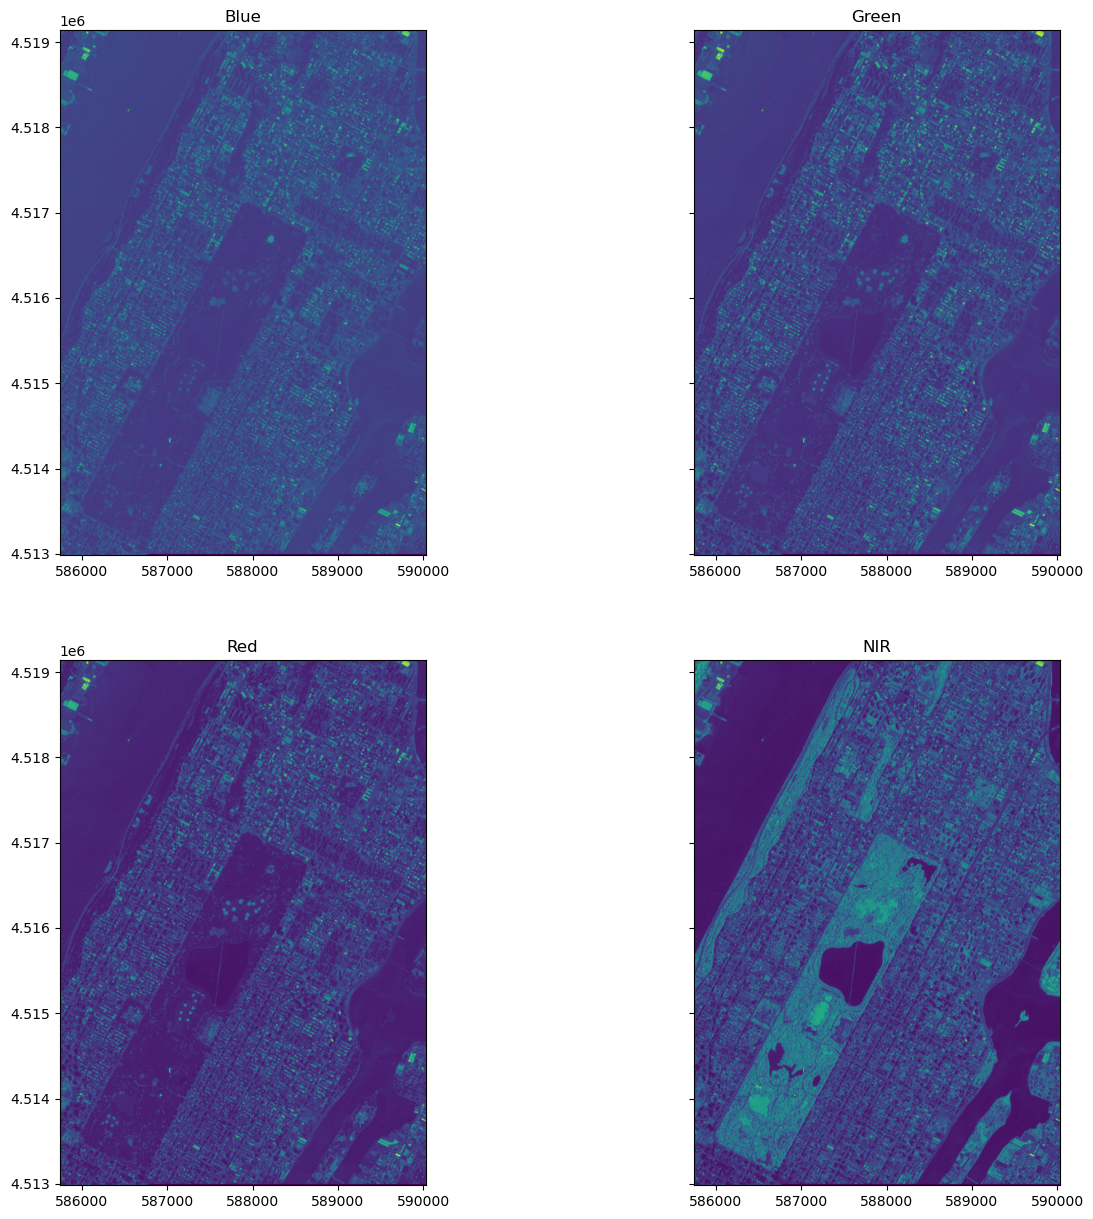

In [37]:
# place multibands next to each other
# Initialize subplots
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(ncols=2, nrows=2, figsize=(15, 15), sharey=True)

# Plot Red, Green and Blue (rgb)
show((nyc, 1), ax=ax1)
show((nyc, 2), ax=ax2)
show((nyc, 3), ax=ax3)
show((nyc, 4), ax=ax4)

# Add titles
ax1.set_title('Blue')
ax2.set_title('Green')
ax3.set_title('Red')
ax4.set_title('NIR')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..2047].


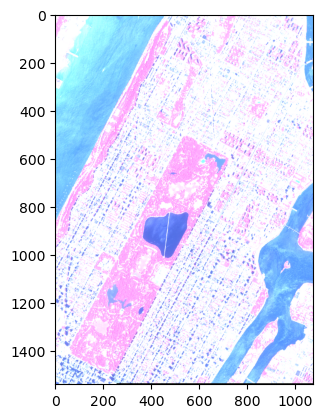

In [38]:
# plot a color composite map 
rgb = np.dstack((nyc.read(4),nyc.read(3),nyc.read(2)))
#plt.imshow(rgb, alpha=1)

plt.imshow(rgb, vmin=rgb.min(), vmax=rgb.max(), alpha=1)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..2047].


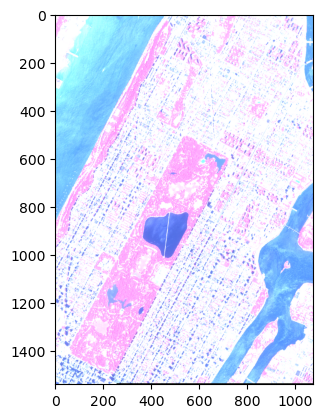

<Axes: >

In [39]:
show(nyc.read([4,3,2]))

#### RGB True color composite 

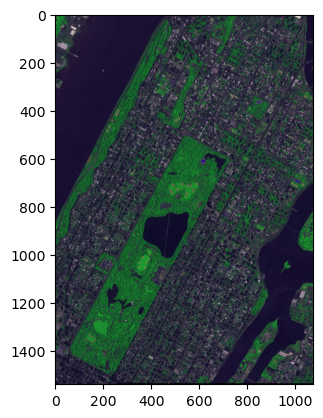

In [40]:
# Need to normalize the data  
def norm(arr):
    return((arr-arr.min())/(arr.max()-arr.min()))
nir = norm(nyc.read(4))
red = norm(nyc.read(3))
grn = norm(nyc.read(2))
blu = norm(nyc.read(1))
#nir = nyc.read(4).astype(float)/1000 
#red = nyc.read(3).astype(float)/1000 
#grn = nyc.read(2).astype(float)/1000 
#blu = nyc.read(1).astype(float)/1000 
      
# Create RGB natural color composite
#rgb = np.dstack((red,grn,blu))
rgb = np.dstack((red,nir,blu))
type(rgb)
# Let's see how our color composite looks like
plt.imshow(rgb)


In [ ]:
#### False color composite 

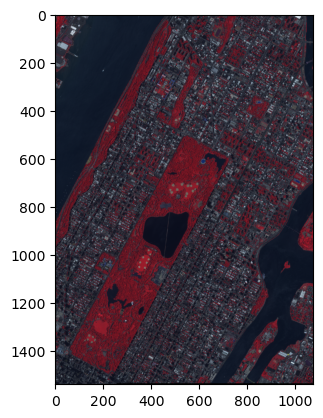

In [41]:
# Create false color composite
rgb = np.dstack((nir,red,grn))
plt.imshow(rgb)

## 5. Raster map algebra 

C:\Users\Wenge\AppData\Local\Temp\ipykernel_924\946463204.py:6: RuntimeWarning: invalid value encountered in divide
  ndvi = (nir-red)/(nir+red)


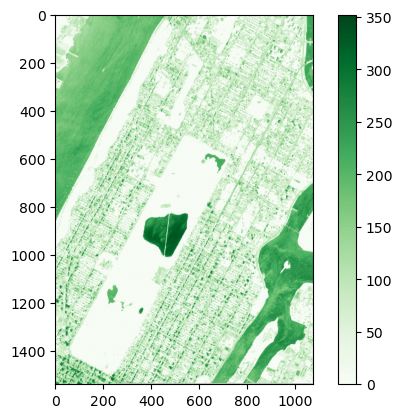

In [42]:
nir = nyc.read(4)
red = nyc.read(3)
grn = nyc.read(2)
blu = nyc.read(1)

ndvi = (nir-red)/(nir+red)
plt.imshow(ndvi,cmap='Greens')
plt.colorbar()

C:\Users\Wenge\AppData\Local\Temp\ipykernel_924\2399934437.py:6: RuntimeWarning: invalid value encountered in divide
  ndvi = (nir-red)/(nir+red)


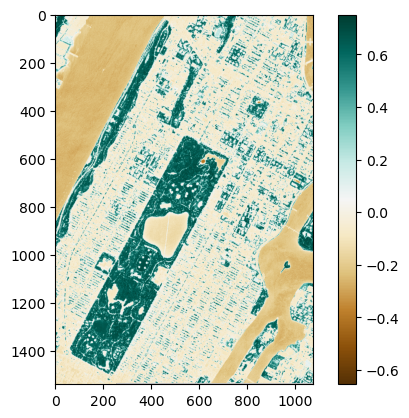

In [44]:
nir = nyc.read(4).astype(float)/1000
red = nyc.read(3).astype(float)/1000
grn = nyc.read(2).astype(float)/1000
blu = nyc.read(1).astype(float)/1000

ndvi = (nir-red)/(nir+red)
#plt.imshow(ndvi,cmap='Greens')
plt.imshow(ndvi,cmap='BrBG')
#plt.imshow(ndvi,cmap='winter')
plt.colorbar()

In [45]:
nyc.close()